In [2]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, field


import torch
import torch.nn as nn
import torch.nn.functional as nnF
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.transforms.v2 as transforms

In [3]:
@dataclass
class Config:
    # Data
    data_root: str = "./data"
    download: bool = True
    image_size: tuple[int, int] = (128, 128)
    train_split: float = 0.8

    # Train
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 1e-4
    weight_decay: float = 0.0
    num_workers: int = 2
    seed: int = 42
    threshold: float = 0.5
    use_amp: bool = True

    # Model
    model_name: str = "unet"  # "unet" | "unet_bn_deeper"
    base_channels: int = 64
    depth: int = 4
    use_batchnorm: bool = False
    dropout: float = 0.0

    # Runtime
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    run_test: bool = True

    # Hyperparam sweep
    sweep_lrs: list[float] = field(default_factory=lambda: [1e-4, 3e-4, 1e-3])
    sweep_batch_sizes: list[int] = field(default_factory=lambda: [16, 32, 64])
    sweep_epochs: int = 5

config = Config()

In [4]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 1,
        base_channels: int = 64,
        depth: int = 4,
        use_batchnorm: bool = False,
        dropout: float = 0.0,
        bilinear: bool = True,
    ):
        super().__init__()
        if depth < 2:
            raise ValueError("depth must be >= 2")

        enc_channels = [base_channels * (2**i) for i in range(depth)]

        self.inc = DoubleConv(in_channels, enc_channels[0], use_batchnorm=use_batchnorm, dropout=dropout)
        self.downs = nn.ModuleList([
            Down(enc_channels[i], enc_channels[i + 1], use_batchnorm=use_batchnorm, dropout=dropout)
            for i in range(depth - 1)
        ])

        bottleneck_channels = enc_channels[-1] * 2
        self.bottleneck = DoubleConv(enc_channels[-1], bottleneck_channels, use_batchnorm=use_batchnorm, dropout=dropout)

        self.ups = nn.ModuleList()
        in_ch = bottleneck_channels
        for skip_ch in reversed(enc_channels):
            out_ch = skip_ch
            self.ups.append(Up(in_ch, skip_ch, out_ch, use_batchnorm=use_batchnorm, dropout=dropout, bilinear=bilinear))
            in_ch = out_ch

        self.outc = nn.Conv2d(enc_channels[0], out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skips: list[torch.Tensor] = []
        x = self.inc(x)
        skips.append(x)
        for down in self.downs:
            x = down(x)
            skips.append(x)

        x = self.bottleneck(skips[-1])
        for up, skip in zip(self.ups, reversed(skips)):
            x = up(x, skip)

        return self.outc(x)

In [5]:
class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()

        layers: list[nn.Module] = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm),
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        if dropout and dropout > 0:
            layers.append(nn.Dropout2d(p=dropout))
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        if dropout and dropout > 0:
            layers.append(nn.Dropout2d(p=dropout))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [6]:
class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_batchnorm: bool = False, dropout: float = 0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv = DoubleConv(in_channels, out_channels, use_batchnorm=use_batchnorm, dropout=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.pool(x))

In [7]:
class Up(nn.Module):
    def __init__(
        self,
        in_channels: int,
        skip_channels: int,
        out_channels: int,
        use_batchnorm: bool = False,
        dropout: float = 0.0,
        bilinear: bool = True,
    ):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels + skip_channels, out_channels, use_batchnorm=use_batchnorm, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = nnF.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

In [8]:
def make_model(cfg: Config) -> nn.Module:
    if cfg.model_name == "unet":
        return UNet(
            in_channels=3,
            out_channels=1,
            base_channels=cfg.base_channels,
            depth=cfg.depth,
            use_batchnorm=cfg.use_batchnorm,
            dropout=cfg.dropout,
        )

    if cfg.model_name == "unet_bn_deeper":
        return UNet(
            in_channels=3,
            out_channels=1,
            base_channels=cfg.base_channels,
            depth=max(cfg.depth, 5),
            use_batchnorm=True,
            dropout=cfg.dropout,
        )

    raise ValueError(f"Unknown model_name: {cfg.model_name}")


In [9]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, image_size=(128, 128), download: bool = True):
        self.root = root
        self.transform = transform
        self.image_size = image_size
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=download)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        image = TF.resize(image, self.image_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=InterpolationMode.NEAREST)

        if self.transform:
            image = self.transform(image)

        mask = TF.pil_to_tensor(mask).float()

        return image, mask

In [10]:
class Trainer:
    def __init__(self, config: Config):
        self.config = config
        self._set_seed(self.config.seed)

        self.transform = transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

        self.model = make_model(config).to(config.device)
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )

        self.scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and config.device.startswith("cuda")))

        self.setup_dataloader()
        self.history: list[dict] = []

    def _set_seed(self, seed: int):
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    def _dice_loss(self, logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        targets = targets.float()

        dims = (1, 2, 3)
        intersection = torch.sum(probs * targets, dim=dims)
        union = torch.sum(probs, dim=dims) + torch.sum(targets, dim=dims)
        dice = (2.0 * intersection + eps) / (union + eps)
        return 1.0 - dice.mean()

    def loss(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = nnF.binary_cross_entropy_with_logits(logits, targets.float())
        dice = self._dice_loss(logits, targets)
        return 0.5 * bce + 0.5 * dice

    @staticmethod
    def _batch_iou_f1(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-6):
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).to(targets.dtype)

        preds = preds.view(preds.shape[0], -1)
        targets = targets.view(targets.shape[0], -1)

        tp = (preds * targets).sum(dim=1)
        fp = (preds * (1 - targets)).sum(dim=1)
        fn = ((1 - preds) * targets).sum(dim=1)

        iou = (tp + eps) / (tp + fp + fn + eps)
        f1 = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        return iou.mean().item(), f1.mean().item()

    def setup_dataloader(self):
        dataset = PetDataset(
            root=self.config.data_root,
            split='trainval',
            transform=self.transform,
            image_size=self.config.image_size,
            download=self.config.download,
        )
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(
            root=self.config.data_root,
            split='test',
            transform=self.transform,
            image_size=self.config.image_size,
            download=self.config.download,
        )

        loader_kwargs = dict(
            batch_size=self.config.batch_size,
            num_workers=self.config.num_workers,
            pin_memory=self.config.device.startswith("cuda"),
        )
        self.train_dataloader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
        self.val_dataloader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
        self.test_dataloader = DataLoader(self.test_dataset, shuffle=False, **loader_kwargs)

    def run(self):
        best_val_iou = -1.0
        best_state = None

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history.append({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_iou": val_iou,
                "val_f1": val_f1,
            })

            if val_iou > best_val_iou:
                best_val_iou = val_iou
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}

            print(
                f"Epoch {epoch+1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}"
            )

        if best_state is not None:
            self.model.load_state_dict(best_state)

        test_metrics = None
        if self.config.run_test:
            print('Testing...')
            test_loss, test_iou, test_f1 = self.test()
            test_metrics = {"test_loss": test_loss, "test_iou": test_iou, "test_f1": test_f1}

            print(
                f"Test Loss: {test_loss:.4f}, "
                f"Test IoU: {test_iou:.4f}, "
                f"Test F1-score: {test_f1:.4f}"
            )

        return self.history, test_metrics

    def plot_history(self, history=None, title: str = "Training curves"):
        if history is None:
            history = self.history

        epochs = [h["epoch"] for h in history]
        train_loss = [h["train_loss"] for h in history]
        val_loss = [h["val_loss"] for h in history]
        val_iou = [h["val_iou"] for h in history]
        val_f1 = [h["val_f1"] for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(title)

        axes[0].plot(epochs, train_loss, label="train")
        axes[0].plot(epochs, val_loss, label="val")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("epoch")
        axes[0].grid(True)
        axes[0].legend()

        axes[1].plot(epochs, val_iou, label="IoU")
        axes[1].plot(epochs, val_f1, label="F1")
        axes[1].set_title("Validation metrics")
        axes[1].set_xlabel("epoch")
        axes[1].grid(True)
        axes[1].legend()

        plt.show()

    def train(self):
        self.model.train()
        epoch_loss = 0.0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):
                outputs = self.model(images)
                loss = self.loss(outputs, masks)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0.0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.loss(outputs, masks)
                val_loss += loss.item()

                iou, f1 = self._batch_iou_f1(outputs, masks, threshold=self.config.threshold)
                iou_scores.append(iou)
                f1_scores.append(f1)

        return val_loss / len(self.val_dataloader), float(np.mean(iou_scores)), float(np.mean(f1_scores))

    def test(self):
        self.model.eval()
        test_loss = 0.0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.loss(outputs, masks)
                test_loss += loss.item()

                iou, f1 = self._batch_iou_f1(outputs, masks, threshold=self.config.threshold)
                iou_scores.append(iou)
                f1_scores.append(f1)

        return test_loss / len(self.test_dataloader), float(np.mean(iou_scores)), float(np.mean(f1_scores))

    def inference_and_plot_samples(self, n_samples: int = 3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= self.config.threshold).astype('float')

                img_vis = (img * 0.5 + 0.5).clamp(0, 1)

                axes[i, 0].imshow(img_vis.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [11]:
trainer = Trainer(config)

/tmp/ipykernel_1294/2500526774.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and config.device.startswith("cuda")))
100%|██████████| 792M/792M [00:39<00:00, 20.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.0MB/s]


  0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_1294/2500526774.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):
100%|██████████| 23/23 [00:04<00:00,  5.37it/s]


Epoch 1 / 15, Train Loss: 0.4546, Val Loss: 0.3545, Val IoU: 0.7075, Val F1-score: 0.8179


100%|██████████| 23/23 [00:04<00:00,  5.16it/s]


Epoch 2 / 15, Train Loss: 0.3586, Val Loss: 0.3238, Val IoU: 0.7376, Val F1-score: 0.8444


100%|██████████| 23/23 [00:05<00:00,  4.17it/s]


...

Epoch 14 / 15, Train Loss: 0.1768, Val Loss: 0.1842, Val IoU: 0.8515, Val F1-score: 0.9155


100%|██████████| 23/23 [00:04<00:00,  5.06it/s]


Epoch 15 / 15, Train Loss: 0.1739, Val Loss: 0.1741, Val IoU: 0.8618, Val F1-score: 0.9221
Testing...


100%|██████████| 115/115 [00:23<00:00,  4.95it/s]


Test Loss: 0.1812, Test IoU: 0.8543, Test F1-score: 0.9161


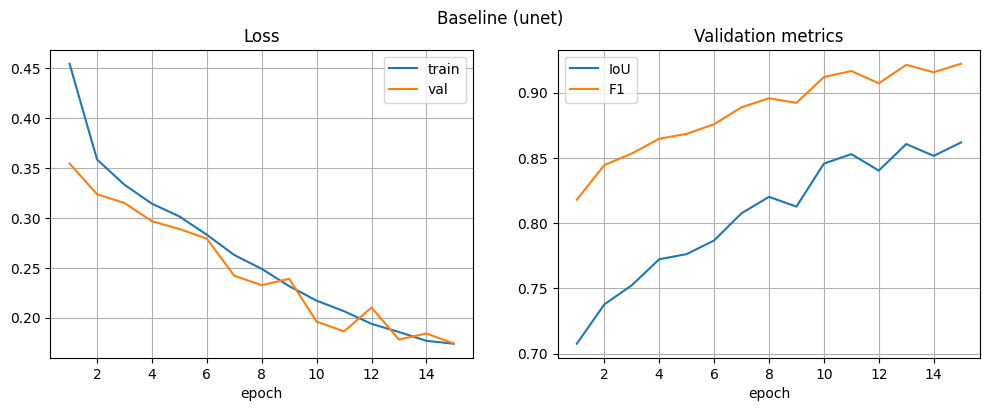

{'test_loss': 0.18117847131646198,
 'test_iou': 0.8542953268341397,
 'test_f1': 0.9160793532495913}

In [12]:
history, test_metrics = trainer.run()
trainer.plot_history(history, title=f"Baseline ({config.model_name})")
test_metrics

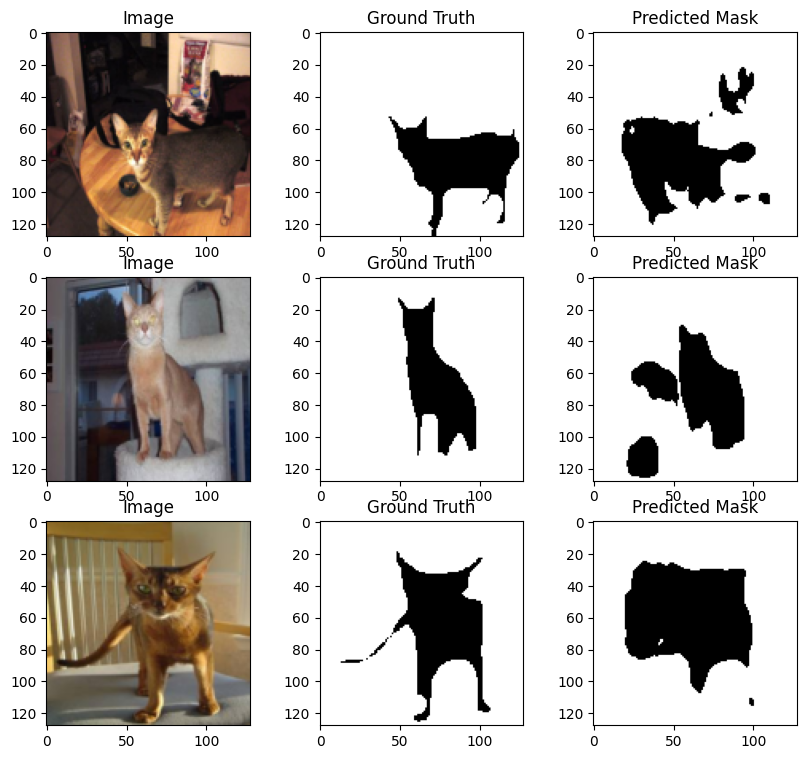

In [13]:
trainer.inference_and_plot_samples(n_samples=3)

#Эксперименты (гиперпараметры + модификация U-Net)
Важно: перебор (grid) по 3 значениям для 2 параметров может занять время.Чтобы ускорить — используем config.sweep_epochs и отключаем test.

In [14]:
from dataclasses import replace

In [15]:
def run_lr_bs_sweep(base_cfg: Config):
    results = []

    for lr in base_cfg.sweep_lrs:
        for bs in base_cfg.sweep_batch_sizes:
            cfg = replace(
                base_cfg,
                learning_rate=lr,
                batch_size=bs,
                epochs=base_cfg.sweep_epochs,
                model_name="unet",
                use_batchnorm=False,
                run_test=False,
            )

            print(f"\n=== Sweep run: lr={lr}, batch_size={bs} ===")
            trainer = Trainer(cfg)
            history, _ = trainer.run()
            best = max(history, key=lambda h: h["val_iou"])

            results.append({
                "lr": lr,
                "batch_size": bs,
                "best_val_iou": best["val_iou"],
                "best_val_f1": best["val_f1"],
            })

    return results

In [16]:
def plot_sweep_heatmap(results, lrs, batch_sizes, metric_key="best_val_iou", title="Sweep"):
    grid = np.full((len(lrs), len(batch_sizes)), np.nan, dtype=np.float32)
    for r in results:
        i = lrs.index(r["lr"])
        j = batch_sizes.index(r["batch_size"])
        grid[i, j] = r[metric_key]

    plt.figure(figsize=(8, 4))
    plt.imshow(grid, aspect="auto")
    plt.colorbar(label=metric_key)
    plt.xticks(range(len(batch_sizes)), batch_sizes)
    plt.yticks(range(len(lrs)), lrs)
    plt.xlabel("batch_size")
    plt.ylabel("learning_rate")
    plt.title(title)

    for i in range(len(lrs)):
        for j in range(len(batch_sizes)):
            if not np.isnan(grid[i, j]):
                plt.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="white")

    plt.show()

1. Перебор lr x batch_size (3x3)


=== Sweep run: lr=0.0001, batch_size=16 ===


/tmp/ipykernel_1294/2500526774.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and config.device.startswith("cuda")))
  0%|          | 0/184 [00:00<?, ?it/s]/tmp/ipykernel_1294/2500526774.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):
100%|██████████| 46/46 [00:05<00:00,  8.07it/s]


Epoch 1 / 5, Train Loss: 0.4144, Val Loss: 0.3408, Val IoU: 0.7500, Val F1-score: 0.8487


100%|██████████| 46/46 [00:05<00:00,  8.66it/s]


Epoch 2 / 5, Train Loss: 0.3324, Val Loss: 0.3116, Val IoU: 0.7659, Val F1-score: 0.8607


...

Epoch 3 / 5, Train Loss: 0.3554, Val Loss: 0.3242, Val IoU: 0.7597, Val F1-score: 0.8570


100%|██████████| 12/12 [00:05<00:00,  2.38it/s]


Epoch 4 / 5, Train Loss: 0.3288, Val Loss: 0.3020, Val IoU: 0.7614, Val F1-score: 0.8588


100%|██████████| 12/12 [00:04<00:00,  2.47it/s]


Epoch 5 / 5, Train Loss: 0.3083, Val Loss: 0.3148, Val IoU: 0.7405, Val F1-score: 0.8460

Best sweep run: {'lr': 0.001, 'batch_size': 16, 'best_val_iou': 0.810946180768635, 'best_val_f1': 0.8882320251153863}


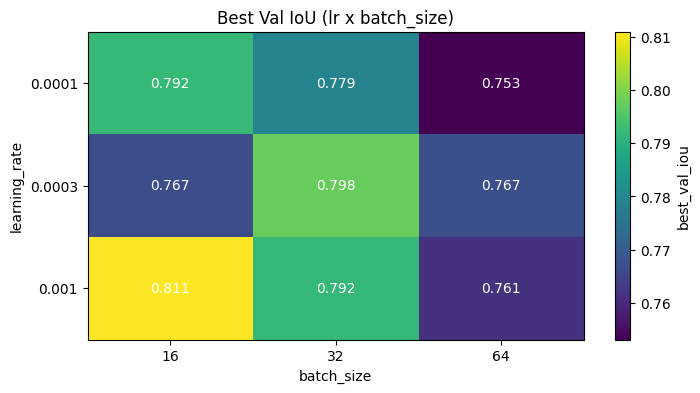

In [17]:
sweep_results = run_lr_bs_sweep(config)
best_run = max(sweep_results, key=lambda r: r["best_val_iou"])
print("\nBest sweep run:", best_run)

plot_sweep_heatmap(
    sweep_results,
    lrs=config.sweep_lrs,
    batch_sizes=config.sweep_batch_sizes,
    metric_key="best_val_iou",
    title="Best Val IoU (lr x batch_size)",
)

2) Идея/модификация: сделать U-Net глубже + BatchNorm (model_name='unet_bn_deeper'). Сравним кривые Val IoU для baseline и модифицированной модели.

/tmp/ipykernel_1294/2500526774.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and config.device.startswith("cuda")))
  0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_1294/2500526774.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):
100%|██████████| 23/23 [00:04<00:00,  4.74it/s]


Epoch 1 / 15, Train Loss: 0.4546, Val Loss: 0.3545, Val IoU: 0.7075, Val F1-score: 0.8179


100%|██████████| 23/23 [00:04<00:00,  4.92it/s]


Epoch 2 / 15, Train Loss: 0.3586, Val Loss: 0.3238, Val IoU: 0.7390, Val F1-score: 0.8452


100%|██████████| 23/23 [00:04<00:00,  4.94it/s]


...

Epoch 14 / 15, Train Loss: 0.1432, Val Loss: 0.1684, Val IoU: 0.8707, Val F1-score: 0.9270


100%|██████████| 23/23 [00:06<00:00,  3.76it/s]


Epoch 15 / 15, Train Loss: 0.1351, Val Loss: 0.1440, Val IoU: 0.8857, Val F1-score: 0.9361
Testing...


100%|██████████| 115/115 [00:28<00:00,  3.98it/s]


Test Loss: 0.1431, Test IoU: 0.8853, Test F1-score: 0.9350


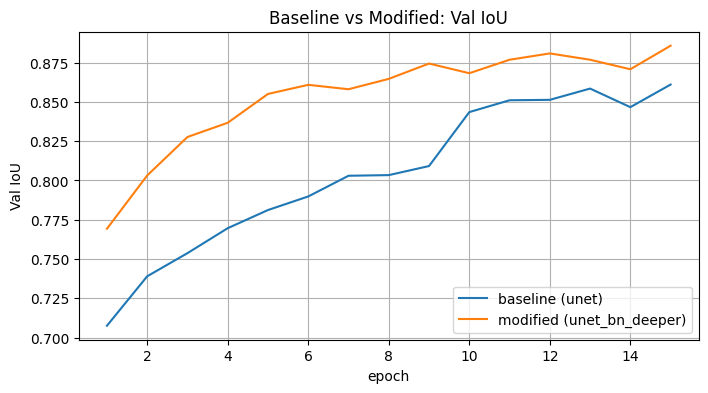


Test metrics baseline: {'test_loss': 0.18145774706550266, 'test_iou': 0.8543108385542165, 'test_f1': 0.9160965592964836}
Test metrics modified: {'test_loss': 0.14312393937421883, 'test_iou': 0.8853319178456845, 'test_f1': 0.9350043716637985}


In [18]:
cfg_baseline = replace(config, model_name="unet", use_batchnorm=False, depth=4, run_test=True)
cfg_modified = replace(config, model_name="unet_bn_deeper", base_channels=64, dropout=0.1, run_test=True)

trainer_base = Trainer(cfg_baseline)
hist_base, test_base = trainer_base.run()

trainer_mod = Trainer(cfg_modified)
hist_mod, test_mod = trainer_mod.run()

epochs_b = [h["epoch"] for h in hist_base]
epochs_m = [h["epoch"] for h in hist_mod]
val_iou_b = [h["val_iou"] for h in hist_base]
val_iou_m = [h["val_iou"] for h in hist_mod]

plt.figure(figsize=(8, 4))
plt.plot(epochs_b, val_iou_b, label="baseline (unet)")
plt.plot(epochs_m, val_iou_m, label="modified (unet_bn_deeper)")
plt.grid(True)
plt.xlabel("epoch")
plt.ylabel("Val IoU")
plt.title("Baseline vs Modified: Val IoU")
plt.legend()
plt.show()

print("\nTest metrics baseline:", test_base)
print("Test metrics modified:", test_mod)

In [19]:
def _best(history, key="val_iou"):
    return max(history, key=lambda h: h[key])


def _fmt_test(test_metrics):
    if not test_metrics:
        return "n/a"
    return (
        f"loss={test_metrics['test_loss']:.4f}, "
        f"IoU={test_metrics['test_iou']:.4f}, "
        f"F1={test_metrics['test_f1']:.4f}"
    )


Выводы

In [20]:

base_best = _best(hist_base, key="val_iou")
mod_best = _best(hist_mod, key="val_iou")
delta_val_iou = mod_best["val_iou"] - base_best["val_iou"]

print("\n=== Summary ===")
print(
    f"Sweep best: lr={best_run['lr']}, batch_size={best_run['batch_size']}, "
    f"best_val_iou={best_run['best_val_iou']:.4f}, best_val_f1={best_run['best_val_f1']:.4f}"
)
print(
    f"Baseline: best_val_iou={base_best['val_iou']:.4f} (epoch {base_best['epoch']}), "
    f"test=({_fmt_test(test_base)})"
)
print(
    f"Modified: best_val_iou={mod_best['val_iou']:.4f} (epoch {mod_best['epoch']}), "
    f"test=({_fmt_test(test_mod)})"
)
print(f"ΔVal IoU (modified - baseline): {delta_val_iou:+.4f}")



=== Summary ===
Sweep best: lr=0.001, batch_size=16, best_val_iou=0.8109, best_val_f1=0.8882
Baseline: best_val_iou=0.8610 (epoch 15), test=(loss=0.1815, IoU=0.8543, F1=0.9161)
Modified: best_val_iou=0.8857 (epoch 15), test=(loss=0.1431, IoU=0.8853, F1=0.9350)
ΔVal IoU (modified - baseline): +0.0247
